# Analyzing march vs. waltz experiment

## What is this 'notebook'?
This is a Jupyter Notebook. It is a tool that allows us to write and execute code in an interactive way. We can also add text, images, and other media to explain what we are doing. This makes it a great tool for data analysis and visualization. In this notebook, we will use Python to analyze the finger-tapping data that we collected during the experiment.

---

In this environment, you can run the code cells by clicking on them and pressing Shift + Enter. You can also edit the code and run it again to see how it works. Don't worry about making mistakes, that's part of the learning process! You can always go back to the original code by clicking File > Revert Notebook to Checkpoint.

---

Enjoy! Don't worry about understanding everything (especially not the code of course). If you're interested, and if you have any questions, feel free to ask!

## First step: Loading the libraries (plugins) that we will use

We load a number of libraries (plugins) that we will use in this notebook. Put your cursor in the cell and press Shift + Enter to run the code!

In [1]:
## Install packages
%pip install pandas numpy matplotlib seaborn statsmodels

## Importing 'packages'
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.graphics.tsaplots import plot_acf
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


## Data preprocessing

Before doing any type of analysis, we need to preprocess the data. This involves cleaning the data, handling missing values, and preparing it for analysis. In this notebook, we will go through the steps of preprocessing the finger-tapping data that we collected during the experiment. We will start by loading the data and then we will perform some basic cleaning and preparation steps.

### Dataset with onsets of the taps

As you might remember, 'onsets' is the term used for the exact time points at which the participants tapped their fingers. We will create one dataset that contains the onsets of the taps for each participant and for each song.

After running the code below, you will have a 'variable' called 'onsets' that contains the onsets of the taps for each participant and for each song. You can take a look at the first few rows of the dataset by running 'onsets.head()'.

In [ ]:
# Create empty dataframe to store onsets
onsets = pd.DataFrame()

# Get list of all .csv files (spreadsheets) that I put in the 'data' folder
filenames = [file for file in os.listdir(os.path.join(".", "data")) if file.endswith('.csv')]

# We go through each file (each participant) and extract the onsets of the taps for each song. We then store this information in the 'onsets' dataframe.
for file in filenames:
    df_response = pd.read_csv(os.path.join(".", "data", file))

    pp_id = df_response.participant[0]

    for filename, trial_df in df_response.groupby('songFileName'):
        stimulus_t_zero = trial_df["stimulus.started"].dropna().values[0]
        resp_onsets_t = trial_df["resp.time"].dropna().values
        resp_onsets = resp_onsets_t - stimulus_t_zero
        # get indices of resp onsets that are smaller than 0 (these are taps that happened before the stimulus started or after the stimulus ended (all stimuli were 15 seconds long)
        resp_onsets_wrong_indices = np.where((resp_onsets < 0) | (resp_onsets > 15))[0]
        resp_onsets = np.delete(resp_onsets, resp_onsets_wrong_indices)
        resp_velocity = trial_df["resp.velocity"].dropna().values
        resp_velocity = np.delete(resp_velocity, resp_onsets_wrong_indices)

        onsets = pd.concat([onsets, pd.DataFrame({
            'pp_id': pp_id,
            'filename': filename.split('/')[-1],
            'onset_i': np.arange(len(resp_onsets)) + 1,
            'onset': resp_onsets,
            'velocity': resp_velocity
        })])

# Finally, we also save the onsets dataframe to a new .csv file in the 'processed' folder, so we can load it later if we want
onsets.to_csv(os.path.join(".", "data", "processed", "onsets.csv"), index=False)

In [56]:
# To take a quick look, we run 'onsets.head()' to see the first few rows of the dataset
onsets.head(100)

,pp_id,filename,onset_i,onset,velocity
0,pilot,K_Alfven_Midsomm.wav,1,10.775337,11.0
1,pilot,K_Alfven_Midsomm.wav,2,11.535601,14.0
2,pilot,K_Alfven_Midsomm.wav,3,11.842394,9.0
3,pilot,K_Alfven_Midsomm.wav,4,12.576164,20.0
4,pilot,K_Alfven_Midsomm.wav,5,12.896238,12.0
...,...,...,...,...,...
13,pilot2,K_Alfven_Midsomm.wav,14,9.984221,6.0
14,pilot2,K_Alfven_Midsomm.wav,15,10.292496,84.0
15,pilot2,K_Alfven_Midsomm.wav,16,10.842644,14.0
16,pilot2,K_Alfven_Midsomm.wav,17,11.125877,48.0


---

One cool things about the way that we recorded the taps is that we also recorded the velocity of the taps. The velocity is a measure of how hard the participant tapped their finger. This is useful for us if we later want to see whether people tapped in twos or in threes, because people who tap in threes might tap harder on the first tap of the triplet. That's why we also included the velocity of the taps in our 'onsets' dataset.

### Dataset with inter-onset intervals (IOIs) of the taps
The inter-onset interval (IOI) is the time difference between two consecutive taps. It is calculated by taking the difference between the onsets of two consecutive taps. We will create another dataset that contains the IOIs of the taps for each participant and for each song. Inter-onset intervals are important because they can give us insights into the timing and rhythm of the taps. For example, if the IOIs are consistent, it might indicate that the participant is tapping in a steady rhythm. If the IOIs are variable, it might indicate that the participant is tapping in a more irregular rhythm.

A confusing difference between onsets and IOIs is that you will have one more onset than IOI, because the first tap does not have a preceding tap to calculate the IOI from. So if you have 10 onsets, you will have 9 IOIs.

--- 

Note that here we do not include the velocity of the taps. That would be difficult to interpret (because one inter-onset interval has two taps, each with its own velocity).

In [ ]:
# Initialze empty dataframe to store inter-onset intervals (IOIs)
iois = pd.DataFrame()

# Go over each participant and each song, and calculate the IOIs by taking the difference between consecutive onsets. We then store this information in the 'iois' dataframe.
for pp_id, df_pp in onsets.groupby('pp_id'):
    for filename, df_trial in df_pp.groupby('filename'):
        iois = pd.concat([iois, pd.DataFrame({
            'pp_id': pp_id,
            'filename': filename,
            'ioi_i': np.arange(len(df_trial) - 1),
            'ioi_s': np.diff(df_trial.onset.values),
            'ioi_ms': np.diff(df_trial.onset.values) * 1000
        })])

# Finally, we also save the iois dataframe to a new .csv file in the 'processed' folder, so we can load it later if we want
iois.to_csv(os.path.join(".", "data", "processed", "iois.csv"), index=False)

In [58]:
# Again, we can take a quick look at the iois dataset by running 'iois.head()'. Now type it yourself below this text and run the cell to see the first few rows of the iois dataset.

## Plotting the data

Basically any quantitative analysis starts with plotting the data. This is important because it allows us to get a first impression of the data, and, most importantly, to see if there are any problems with it. 

In this section, we will go through some basic plotting techniques that we can use to visualize the finger-tapping data that we collected during the experiment. We will start by plotting the onsets of the taps and then we will plot the inter-onset intervals (IOIs) of the taps.

---

Below we first produce a histogram of the inter-onset intervals (IOIs) split up by song. This allows us to see if there are any differences in the IOIs between the different songs. We can also see if there are any outliers in the data. Outliers are data points that are very different from the rest of the data, and they can sometimes indicate a problem with the data (e.g., a participant who was not paying attention and tapped randomly, or a programming error in the experiment).

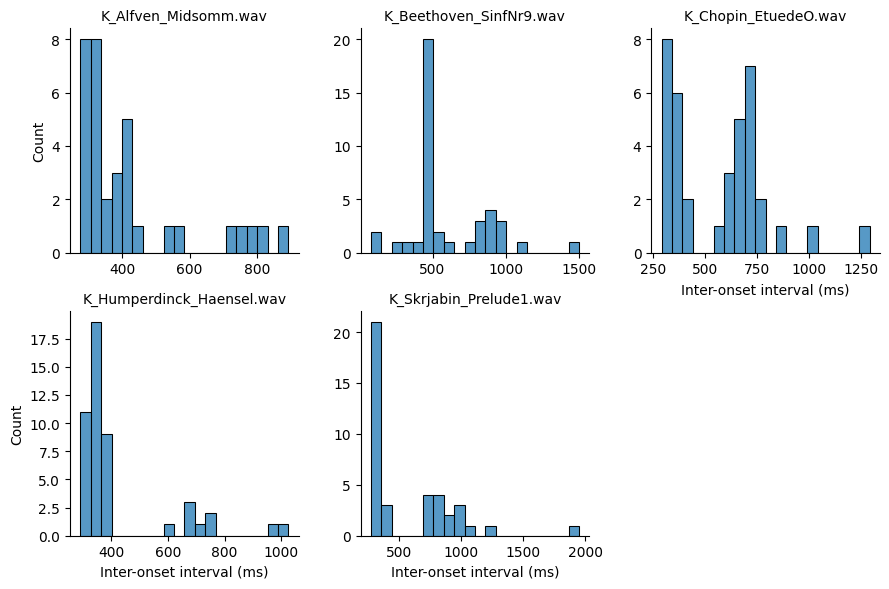

In [59]:
# Histogram of IOIs, with a facet grid by filename
g = sns.FacetGrid(iois, col="filename", col_wrap=3, sharex=False, sharey=False)
g.map(sns.histplot, "ioi_ms", bins=20)
g.set_axis_labels("Inter-onset interval (ms)", "Count")
g.set_titles(col_template="{col_name}")

---

Since we also recorded how hard the participants tapped their fingers (i.e. the velocity), we can for instance see whether people tapped harder at the beginning of a song than at the end.


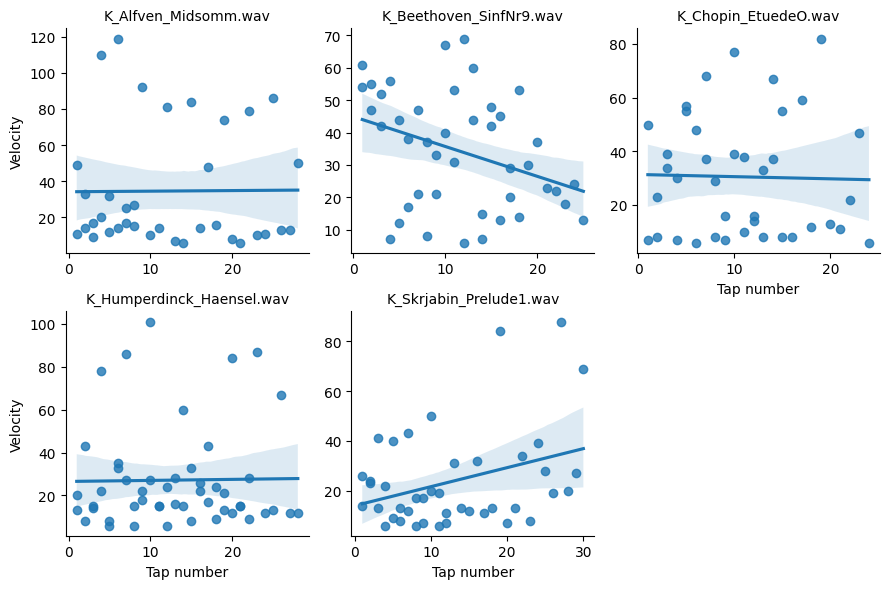

In [60]:
# Histogram of IOIs, with a facet grid by filename
g = sns.FacetGrid(onsets, col="filename", col_wrap=3, sharex=False, sharey=False)
g.map(sns.regplot, "onset_i", "velocity")
g.set_axis_labels("Tap number", "Velocity")
g.set_titles(col_template="{col_name}")

---

So? Did people tap harder at the beginning of a song than at the end?

### Mean tapping rate (sort of tapping tempo)
While we cannot infer tempo from these data (that would require us to know what the pulse/beat is), we can calculate the mean tapping rate for each participant and each song. The mean tapping rate is calculated by taking the average of the inter-onset intervals (IOIs) for each participant and each song, and then converting it to taps per minute (by taking the inverse of the mean IOI and multiplying it by 60,000 to convert from milliseconds to minutes). This can give us an idea of how fast or slow participants were tapping on average for each song.

Let's now look at each participant individually, and each song individually. Each participant has a different colour (hue), and each song has a different column.

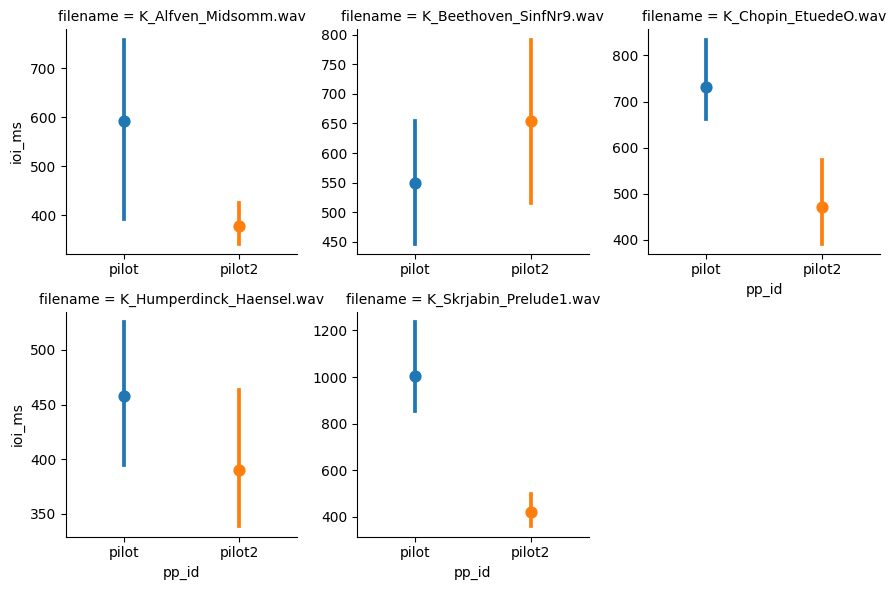

In [ ]:
g = sns.FacetGrid(iois, col="filename", col_wrap=3, sharex=False, sharey=False)
g.map(sns.pointplot, "pp_id", "ioi_ms", "pp_id", palette="tab10", legend=False)

### Length of the inter-onset intervals (IOIs) over time
We can also look at how the inter-onset intervals (IOIs) change over time. This can give us insights into whether participants were tapping in a steady rhythm or if their tapping became more irregular over time. We can plot the IOIs over time for each participant and for each song to see if there are any patterns in the data. For example, we might see that participants started tapping in a steady rhythm but then became more irregular as the song went on, or we might see that participants were tapping in a steady rhythm throughout the song.

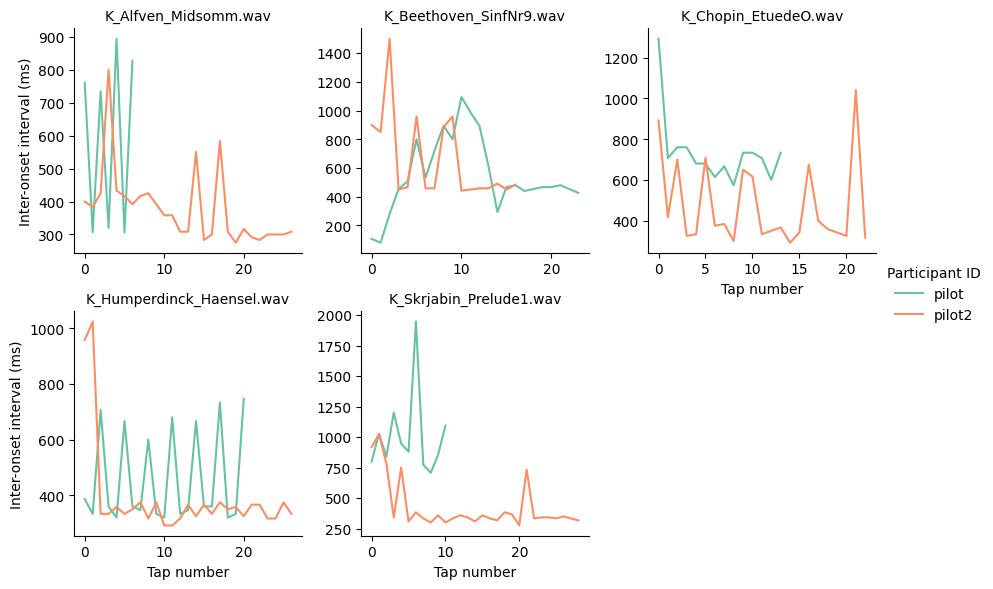

In [62]:
g = sns.FacetGrid(iois, col="filename", col_wrap=3, sharex=False, sharey=False, hue="pp_id", palette="Set2")
g.map(sns.lineplot, "ioi_i", "ioi_ms")
g.set_axis_labels("Tap number", "Inter-onset interval (ms)")
g.set_titles(col_template="{col_name}")
g.add_legend(title="Participant ID")

## The main research question: Did people tap in twos or in threes?
The main research question of this experiment is whether people tapped in twos or in threes.

To look at this, we will make us of the velocity of the taps. The idea is that if people tapped in threes, they might have tapped harder on the first tap of the triplet than on the second and third tap. If people tapped in twos, we would not expect to see this pattern.

If you're not familiar with autocorrelation, it is a measure of how similar a signal is to itself at different time lags. In this case, we can use autocorrelation to see if there are any repeating patterns in the velocity of the taps. If there is a strong autocorrelation at a lag of 3 taps, it might indicate that people were tapping in threes. This is because a hard tap at, let's say, tap number 3 would then also mean a hard tap 3 taps later (i.e. at tap number 6, 9, 12, etc.). So if people tapped in threes, we would expect to see a strong autocorrelation at a lag of 3 taps.

ACF stands for autocorrelation function. If you want to learn more about correlations in general, and about autocorrelation in particular, you can check out this post: https://medium.com/data-science/the-intuition-behind-correlation-62ca11a3c4a

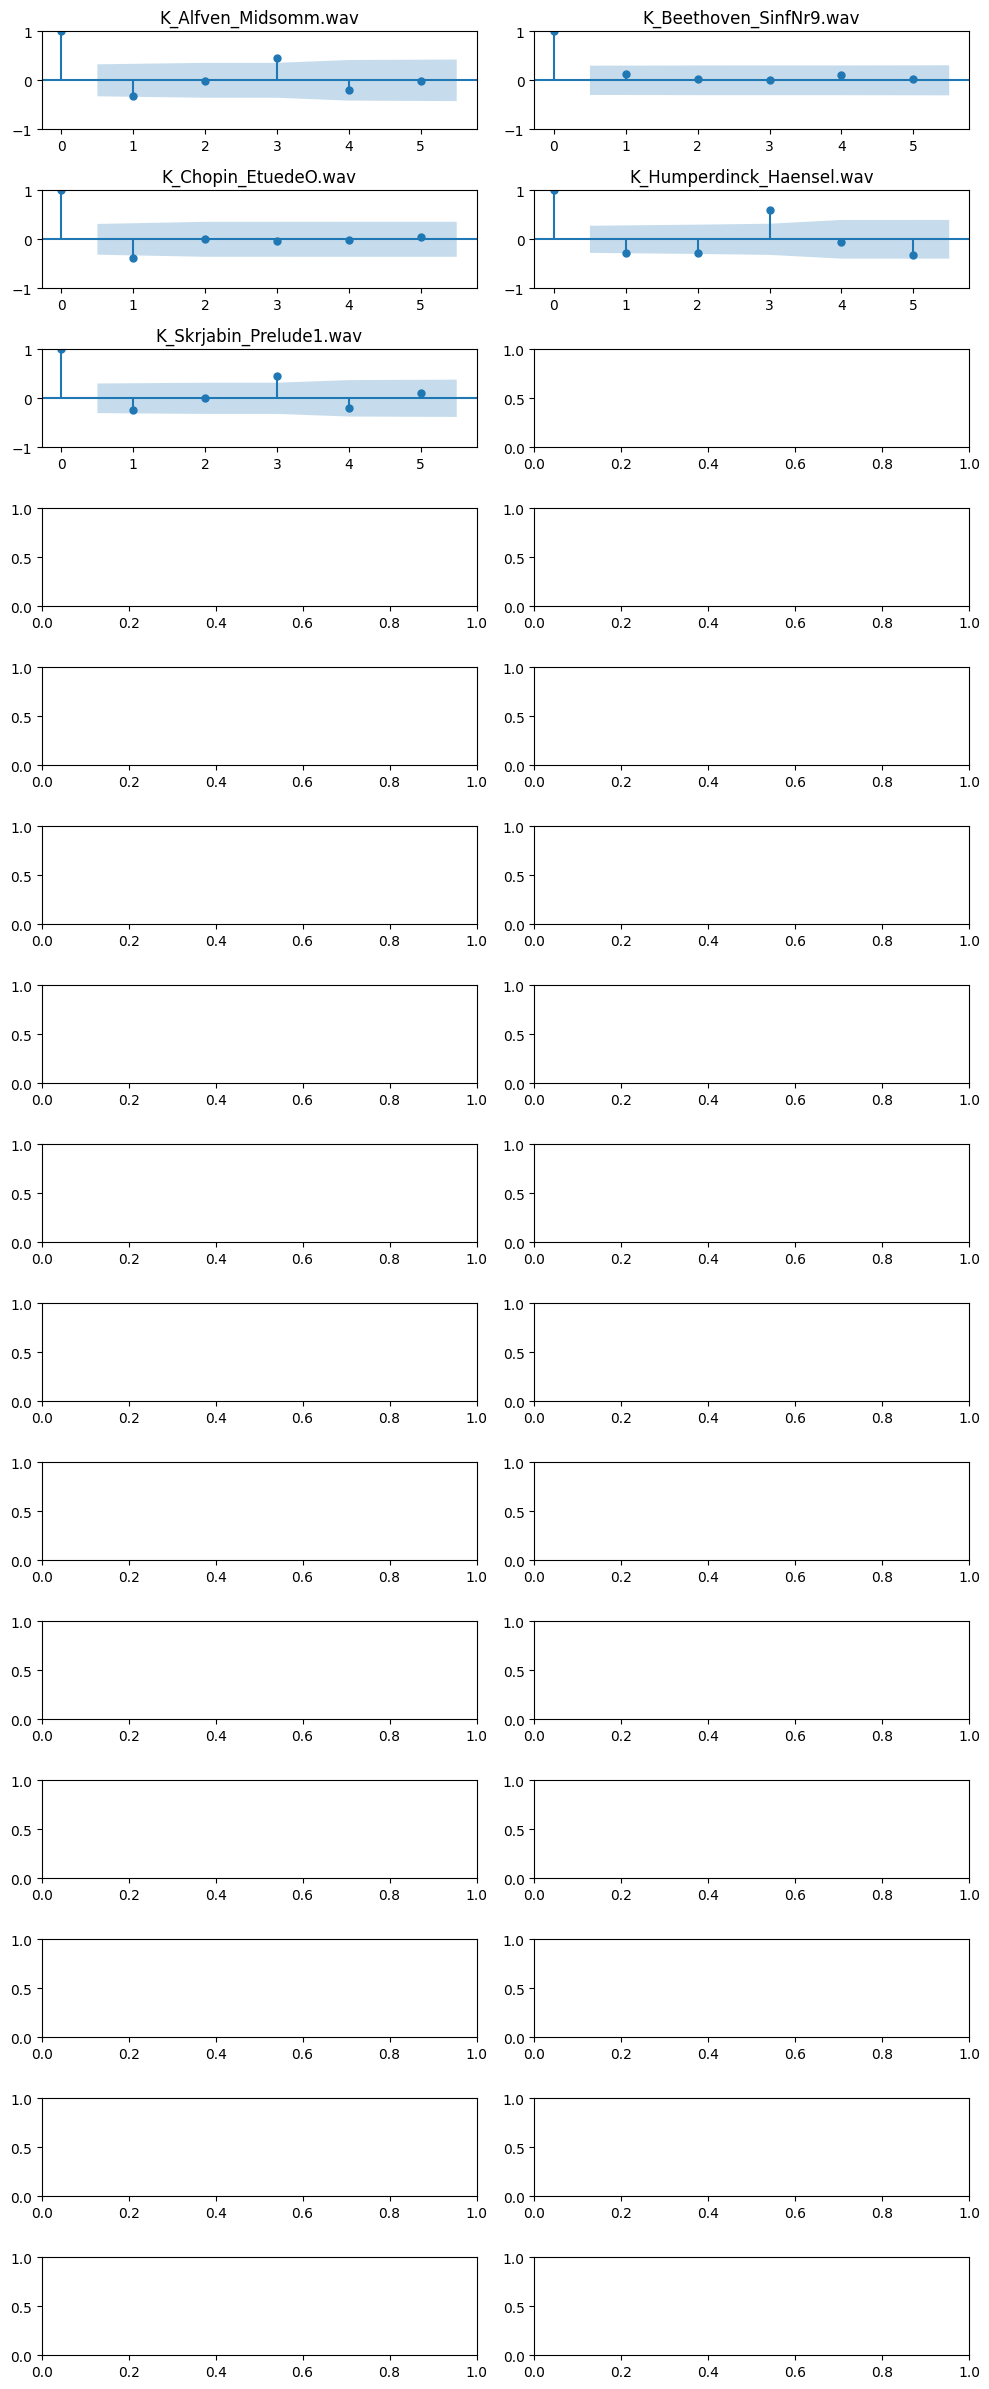

In [66]:
fig, axs = plt.subplots(15, 2 ,figsize=(10, 24), tight_layout=True)

i = 0

for stim, stim_df in onsets.groupby('filename'):
    plot_acf(stim_df.velocity, lags=5, title=f"{stim}", ax=axs[i // 2, i % 2])
    axs[i // 2, i % 2].set_title(f"{stim}")
    i += 1

Do you spot a pattern in the autocorrelation plots above? Did people tap in twos or in threes?

---

That's it for this notebook! If you didn't yet, take a look at the other notebook (the one called ``attack_experiment.ipynb``). Otherwise, see you next week and hope you'll have a nice Easter, or that you've already had a nice Easter!

---

Jelle van der Werff